# **Clasificador de imágenes: Modelo 4.2**
---

Autores: Andrés Barroso Soriano y Paula Santana García

Universidad de Las Palmas de Gran Canaria, Curso 2025 - 2026

### **CAMBIOS RESPECTO AL MODELO ANTERIOR**

En este modelo probamos a ajustar un poco más ResNet18 en lugar de dejarla casi congelada como antes. Esta vez dejamos que las últimas capas siguieran aprendiendo y añadimos varios aumentos de datos (recortes, giros y cambios de color) para que la red viera más variedad de ejemplos. También subimos el batch size, incluimos dropout para evitar que memorizara demasiado y cambiamos el scheduler por uno que suele dar un entrenamiento más estable. La idea era que el modelo se adaptara mejor a las piezas de ajedrez sin perder generalización.

### **RESULTADOS OBTENIDOS**

Con estos cambios el modelo llegó a un 86.26% de accuracy en el test, mejorando bastante respecto a la versión anterior. Se nota que dejar entrenar parte de las capas profundas y añadir más variación a las imágenes le ha ayudado a reconocer mejor las piezas. En general, este ha sido el modelo que mejor ha funcionado hasta ahora dentro de nuestras pruebas.

Saving dataset4.zip to dataset4 (1).zip
Total imágenes: 651
Entrenamiento: 455
Validación: 65
Prueba: 131
Clases: ['Bishop', 'King', 'Knight', 'Pawn', 'Queen', 'Rook']
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 172MB/s]


Epoch [1/25] - Train Loss: 1.9467, Train Acc: 21.10% | Val Loss: 1.5363, Val Acc: 49.23%
Epoch [2/25] - Train Loss: 1.3279, Train Acc: 47.47% | Val Loss: 1.1345, Val Acc: 60.00%
Epoch [3/25] - Train Loss: 1.0660, Train Acc: 57.58% | Val Loss: 0.8417, Val Acc: 67.69%
Epoch [4/25] - Train Loss: 0.8441, Train Acc: 68.35% | Val Loss: 0.6300, Val Acc: 69.23%
Epoch [5/25] - Train Loss: 0.6724, Train Acc: 76.26% | Val Loss: 0.6527, Val Acc: 70.77%
Epoch [6/25] - Train Loss: 0.5482, Train Acc: 82.86% | Val Loss: 0.6436, Val Acc: 67.69%
Epoch [7/25] - Train Loss: 0.4987, Train Acc: 85.05% | Val Loss: 0.5567, Val Acc: 72.31%
Epoch [8/25] - Train Loss: 0.4607, Train Acc: 84.62% | Val Loss: 0.4876, Val Acc: 78.46%
Epoch [9/25] - Train Loss: 0.3791, Train Acc: 89.45% | Val Loss: 0.5246, Val Acc: 70.77%
Epoch [10/25] - Train Loss: 0.3673, Train Acc: 89.89% | Val Loss: 0.4467, Val Acc: 76.92%
Epoch [11/25] - Train Loss: 0.3199, Train Acc: 90.77% | Val Loss: 0.4312, Val Acc: 80.00%
Epoch [12/25] - Tra

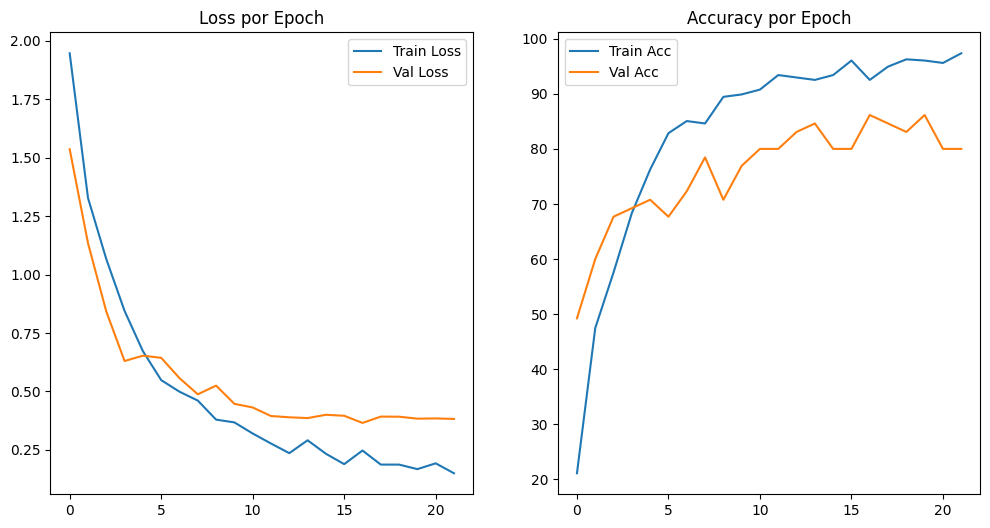

Accuracy del modelo en test: 86.26%


<Figure size 800x600 with 0 Axes>

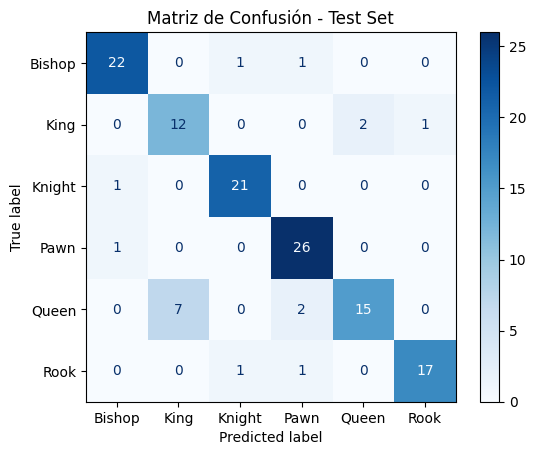

In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, Subset
from torchvision.models import resnet18, ResNet18_Weights
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import os, zipfile
from google.colab import files

import random
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def seed_everything(seed):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
    np.random.seed(seed)
    random.seed(seed)

seed_everything(42)

# =============================
# SUBIR Y EXTRAER DATASET
# =============================
uploaded = files.upload()
with zipfile.ZipFile("dataset4.zip", 'r') as zip_ref:
    zip_ref.extractall("dataset4")

# =============================
# TRANSFORMACIONES
# =============================
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),      # Aumentamos el tamaño inicial para mejor recorte
    transforms.RandomCrop(224),         # Recorte aleatorio para variabilidad
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1,0.1), scale=(0.9,1.1)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])

test_transform = val_transform

# =============================
# DATASETS
# =============================
full_dataset = datasets.ImageFolder(root="dataset4/dataset4")

train_size = int(0.7 * len(full_dataset))
val_size = int(0.1 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_subset, val_subset, test_subset = random_split(full_dataset, [train_size, val_size, test_size])

train_data = datasets.ImageFolder(root="dataset4/dataset4", transform=train_transform)
train_data = Subset(train_data, train_subset.indices)

val_data = datasets.ImageFolder(root="dataset4/dataset4", transform=val_transform)
val_data = Subset(val_data, val_subset.indices)

test_data = datasets.ImageFolder(root="dataset4/dataset4", transform=test_transform)
test_data = Subset(test_data, test_subset.indices)

# =============================
# DATALOADERS
# =============================
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)    # Aumentamos batch_size
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

print(f"Total imágenes: {len(full_dataset)}")
print(f"Entrenamiento: {len(train_data)}")
print(f"Validación: {len(val_data)}")
print(f"Prueba: {len(test_data)}")
print(f"Clases: {full_dataset.classes}")

# =============================
# MODELO PREENTRENADO (ResNet18 moderno)
# =============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Cargamos ResNet18 con pesos preentrenados modernos
weights = ResNet18_Weights.DEFAULT
model = resnet18(weights=weights)

# Congelamos todas las capas excepto las últimas (layer4 y fc para fine-tuning)
for name, param in model.named_parameters():
    if 'layer4' in name or 'fc' in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

# Reemplazamos la última capa fully connected con dropout para regularización
num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.5),            # Agregamos dropout
    nn.Linear(num_features, 6)
)
model = model.to(device)

# =============================
# CRITERIO, OPTIMIZADOR Y SCHEDULER
# =============================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.0001, weight_decay=1e-4)  # LR más bajo, weight_decay
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=25)  # Mejoramos Scheduler

# =============================
# ENTRENAMIENTO
# =============================
epochs = 25  # Aumentamos epochs
train_loss_list, val_loss_list = [], []
train_acc_list, val_acc_list = [], []

best_val_acc = 0.0
patience = 5
counter = 0

for epoch in range(epochs):
    # ----- Entrenamiento -----
    model.train()
    running_loss, correct_train, total_train = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        correct_train += (predicted == labels).sum().item()
        total_train += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct_train / total_train

    # ----- Validación -----
    model.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct_val += (predicted == labels).sum().item()
            total_val += labels.size(0)
    val_loss /= len(val_loader)
    val_acc = 100 * correct_val / total_val

    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss)
    train_acc_list.append(train_acc)
    val_acc_list.append(val_acc)

    scheduler.step()

    # Early stopping
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        counter = 0
        torch.save(model.state_dict(), 'best_model.pth')  # Guardamos el mejor modelo
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping activado")
            break

    print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {train_loss:.4f}, "
          f"Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

# Cargamos el mejor modelo
model.load_state_dict(torch.load('best_model.pth'))

# =============================
# GRAFICAS DE PROGRESO
# =============================
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.plot(train_loss_list, label='Train Loss')
plt.plot(val_loss_list, label='Val Loss')
plt.legend()
plt.title('Loss por Epoch')

plt.subplot(1,2,2)
plt.plot(train_acc_list, label='Train Acc')
plt.plot(val_acc_list, label='Val Acc')
plt.legend()
plt.title('Accuracy por Epoch')
plt.show()

# =============================
# EVALUACIÓN FINAL EN TEST
# =============================
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy del modelo en test: {100 * correct / total:.2f}%')

# =============================
# MATRIZ DE CONFUSIÓN
# =============================
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=full_dataset.classes)
plt.figure(figsize=(8,6))
disp.plot(cmap="Blues", values_format='d')
plt.title("Matriz de Confusión - Test Set")
plt.show()
